#This here we re building a workflow to generate a tweet, evaluate it and then based on the evaluation either approve it or send it for improvement.
#Bullet point about this flow :
#- We start with an initial state that contains the topic for the tweet, the current iteration and the maximum number of iterations allowed.
#- We then invoke the workflow with this initial state.
#- The workflow will generate a tweet based on the topic and then evaluate it.  
#- The evaluation node will return a structured output that contains the evaluation result and feedback for improvement if needed.
#- We then route the flow based on the evaluation result. If the tweet is approved or

In [112]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph ,START, END 
from typing import TypedDict , Annotated , operator ,Literal
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage,HumanMessage
import operator
from dotenv import load_dotenv
load_dotenv(override=True)
import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [113]:
generator_llm=ChatGroq(model="llama-3.1-8b-instant")

evaluator_llm=ChatGroq(model="llama-3.3-70b-versatile")

optimizer_llm=ChatGroq(model="llama-3.1-8b-instant")


In [114]:
class TweetEvaluation(BaseModel):
   evaluation: Literal['approved','need improvement'] = Field (..., description="The evaluation result of the generated tweet")
   feedback:str=Field(...,description="Feedback for improving the tweet if the evaluation is 'need improvement'")

In [115]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [116]:
#State

class TweetState(TypedDict):
    topic:str
    tweet:str
    evaluation:Literal["approved","needs_improvement"]
    feedback:str
    iteration:int
    max_iteration: int

    tweet_history  : Annotated[list[str],operator.add]
    feedback_history  : Annotated[list[str],operator.add]


In [117]:
def generate_tweet(state: TweetState):

    #prompt
    messages = [
        SystemMessage(content="you are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
        Write a short ,original, and hillarious tweet on the topic: "{state['topic']}".

        Rules:
        - MAX 280 characters.
        - The tweet must be original and not a copy of an existing tweet.
        -Donot use question-answer format.
        -Think in meme logic,punchlines or relatable takes to create a viral tweet.
        -use simple and day to day language to make it more relatable and engaging.
        """)
    ]

    response = generator_llm.invoke(messages).content

    #response

    return {'tweet':response , 'tweet_history':[response]}

In [118]:
def evaluate_tweet(state: TweetState):
    #prompt
    messages = [
        SystemMessage(content= "you are a senior social media manager with a keen eye for viral content and deep understanding of Twitter/X dynamics."),
        HumanMessage(content=f"""
        Evaluate the following tweet based on its potential to go viral and its alignment with the topic "{state['topic']}":
        "{state['tweet']}"
        Evaluation Criteria:
        1. Virality Potential: Does the tweet have a catchy hook, relatable content, or a unique perspective that could resonate with a wide audience?
        2. Relevance to Topic: Does the tweet effectively address the topic and provide a
        fresh take on it?
        3. Originality: Is the tweet original and not a copy of existing content?
        4. Clarity and Engagement: Is the tweet clear, concise, and likely to engage users through likes, retweets, or comments?

        Auto-reject if:
        - The tweet is off-topic or does not effectively address the topic.
        - The tweet lacks originality and appears to be a copy of existing content.
        - The tweet is unclear, overly complex, or unlikely to engage users.

        ###Respond ONLY in structured format as below:
        -evaluation : "approved" or "needs_improvement"
        -feedback: One paragraph explaining weakness or strength of the tweet.
         """)
    ]

    response = structured_evaluator_llm.invoke(messages)

    
    return {'evaluation':response.evaluation,'feedback':response.feedback, 'feedback_history':[response.feedback]}

In [119]:
def optimize_tweet(state: TweetState):
    #prompt
    messages = [
        SystemMessage(content="you punch up[ tweets for virality and humor based on given feedback]"),
        HumanMessage(content=f"""
        Improve the tweet based on feedbak : "{state['feedback']}"

        Topic:"{state['topic']}"
        Original Tweet:"{state['tweet']}"

        Re-write it as short , viral-worthy tweet .Avoid QnA style format and stay uner 280 characters
        """)
    ]
    #response   
    response = optimizer_llm.invoke(messages).content

    iteration = state['iteration'] + 1

    return {'tweet':response, 'iteration': iteration , 'tweet_history': [response]}
    
    

In [120]:
def route_evaluation(State: TweetState):
    if State['evaluation'] == 'approved' or State['iteration'] >= State['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

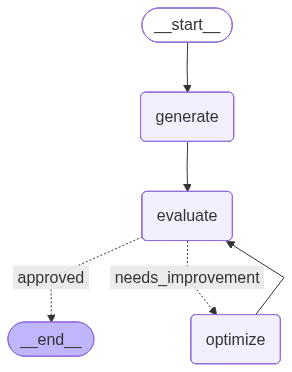

In [121]:
graph = StateGraph(TweetState)

graph.add_node('generate',generate_tweet)
graph.add_node('evaluate',evaluate_tweet)
graph.add_node('optimize',optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', route_evaluation,{'approved':END, 'needs_improvement':'optimize'}),
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()
workflow



In [123]:
initial_state = {
    'topic':"Indian Railways",
    'iteration':1,
    'max_iteration':5,
}
workflow.invoke(initial_state)

{'topic': 'Indian Railways',
 'tweet': '"Just got a \'seat\' on an Indian Railways train... turns out it\'s actually a \'seat\' in a crowded corridor & a \'view\' of 17 other people\'s faces. Chai, samosas, and claustrophobia, here I come #IndianRailways #TrainLife"',
 'evaluation': 'approved',
 'feedback': "The tweet effectively addresses the topic of Indian Railways, providing a relatable and humorous take on the experience of traveling by train in India. The use of hashtags #IndianRailways and #TrainLife increases its discoverability, while the witty observation about the 'seat' in a crowded corridor and the mention of 'chai, samosas, and claustrophobia' adds a touch of originality and cultural relevance, making it likely to resonate with a wide audience and go viral.",
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['"Just got a \'seat\' on an Indian Railways train... turns out it\'s actually a \'seat\' in a crowded corridor & a \'view\' of 17 other people\'s faces. Chai, 